Phase 1: Data pre-processing

Conversion of raw waveforms audio format (.wav) into log scaled Mel spectrograms

Cell 1: Import required libraries

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ip

Cell 2: Load all audio files and display 1 of each genre

In [ ]:
gtzan_dir = '/content/drive/MyDrive/genres_original'
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

loaded_audio = []     # To store: (genre, filename, raw_audio, sample_rate)
previewed_files = []  # To track the 10 specific files we display

for genre in genres:
    folder_path = os.path.join(gtzan_dir, genre)
    if not os.path.exists(folder_path): continue

    files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.wav', '.au'))])

    displayed_first = False
    for file_name in files:
        file_path = os.path.join(folder_path, file_name)

        try:
            # Load full duration audio into memory (duration parameter removed)
            y, sr = librosa.load(file_path)
            loaded_audio.append((genre, file_name, y, sr))

            # Display first working file of each genre
            if not displayed_first:
                previewed_files.append(file_name)
                print(f"Genre: {genre.capitalize()} (Loaded: {file_name})")
                display(ip.Audio(data=y, rate=sr))
                displayed_first = True

        except Exception as e:
            print(f"Skipping corrupted file: {file_name} due to error: {e}")

Genre: Blues (Loaded: blues.00000.wav)


Genre: Classical (Loaded: classical.00000.wav)


Genre: Country (Loaded: country.00000.wav)


Cell 2.5: Mel-Spectrogram Extraction Parameters Reference

y: The raw 1D audio time-series array loaded from your 30 second music file.

sr: The audio sampling rate, which defaults to 22050 Hz.

n_fft: The window length of 2048 samples used to break the audio into analysis frames.

hop_length: The step size of 512 samples the window slides forward to calculate the next frame.

n_mels: The number of Mel filters used to divide the vertical frequency axis, explicitly set to 128.

fmin: The minimum frequency bound for your feature extraction, which defaults to 0 Hz.

fmax: The maximum frequency bound for your feature extraction, which defaults to half of the sampling rate, or 11025 Hz.

Cell 3: Extract Mel Spectrogram

In [ ]:
mel_spectrograms = [] # To store: (genre, filename, mel_spec, sample_rate)

for genre, file_name, y, sr in loaded_audio:
    # Extract feature from the loaded raw audio
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spectrograms.append((genre, file_name, mel_spec, sr))

Cell 4: Convert into decibels (Log scale)

In [ ]:
mel_spectrograms_db = [] # To store: (genre, filename, mel_db, sample_rate)

for genre, file_name, mel_spec, sr in mel_spectrograms:
    # Convert to log scale
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spectrograms_db.append((genre, file_name, mel_db, sr))

Cell 5: Save all audio files and display only the spectrogram of same 10 audio files

Saved 999 total spectrograms in memory.


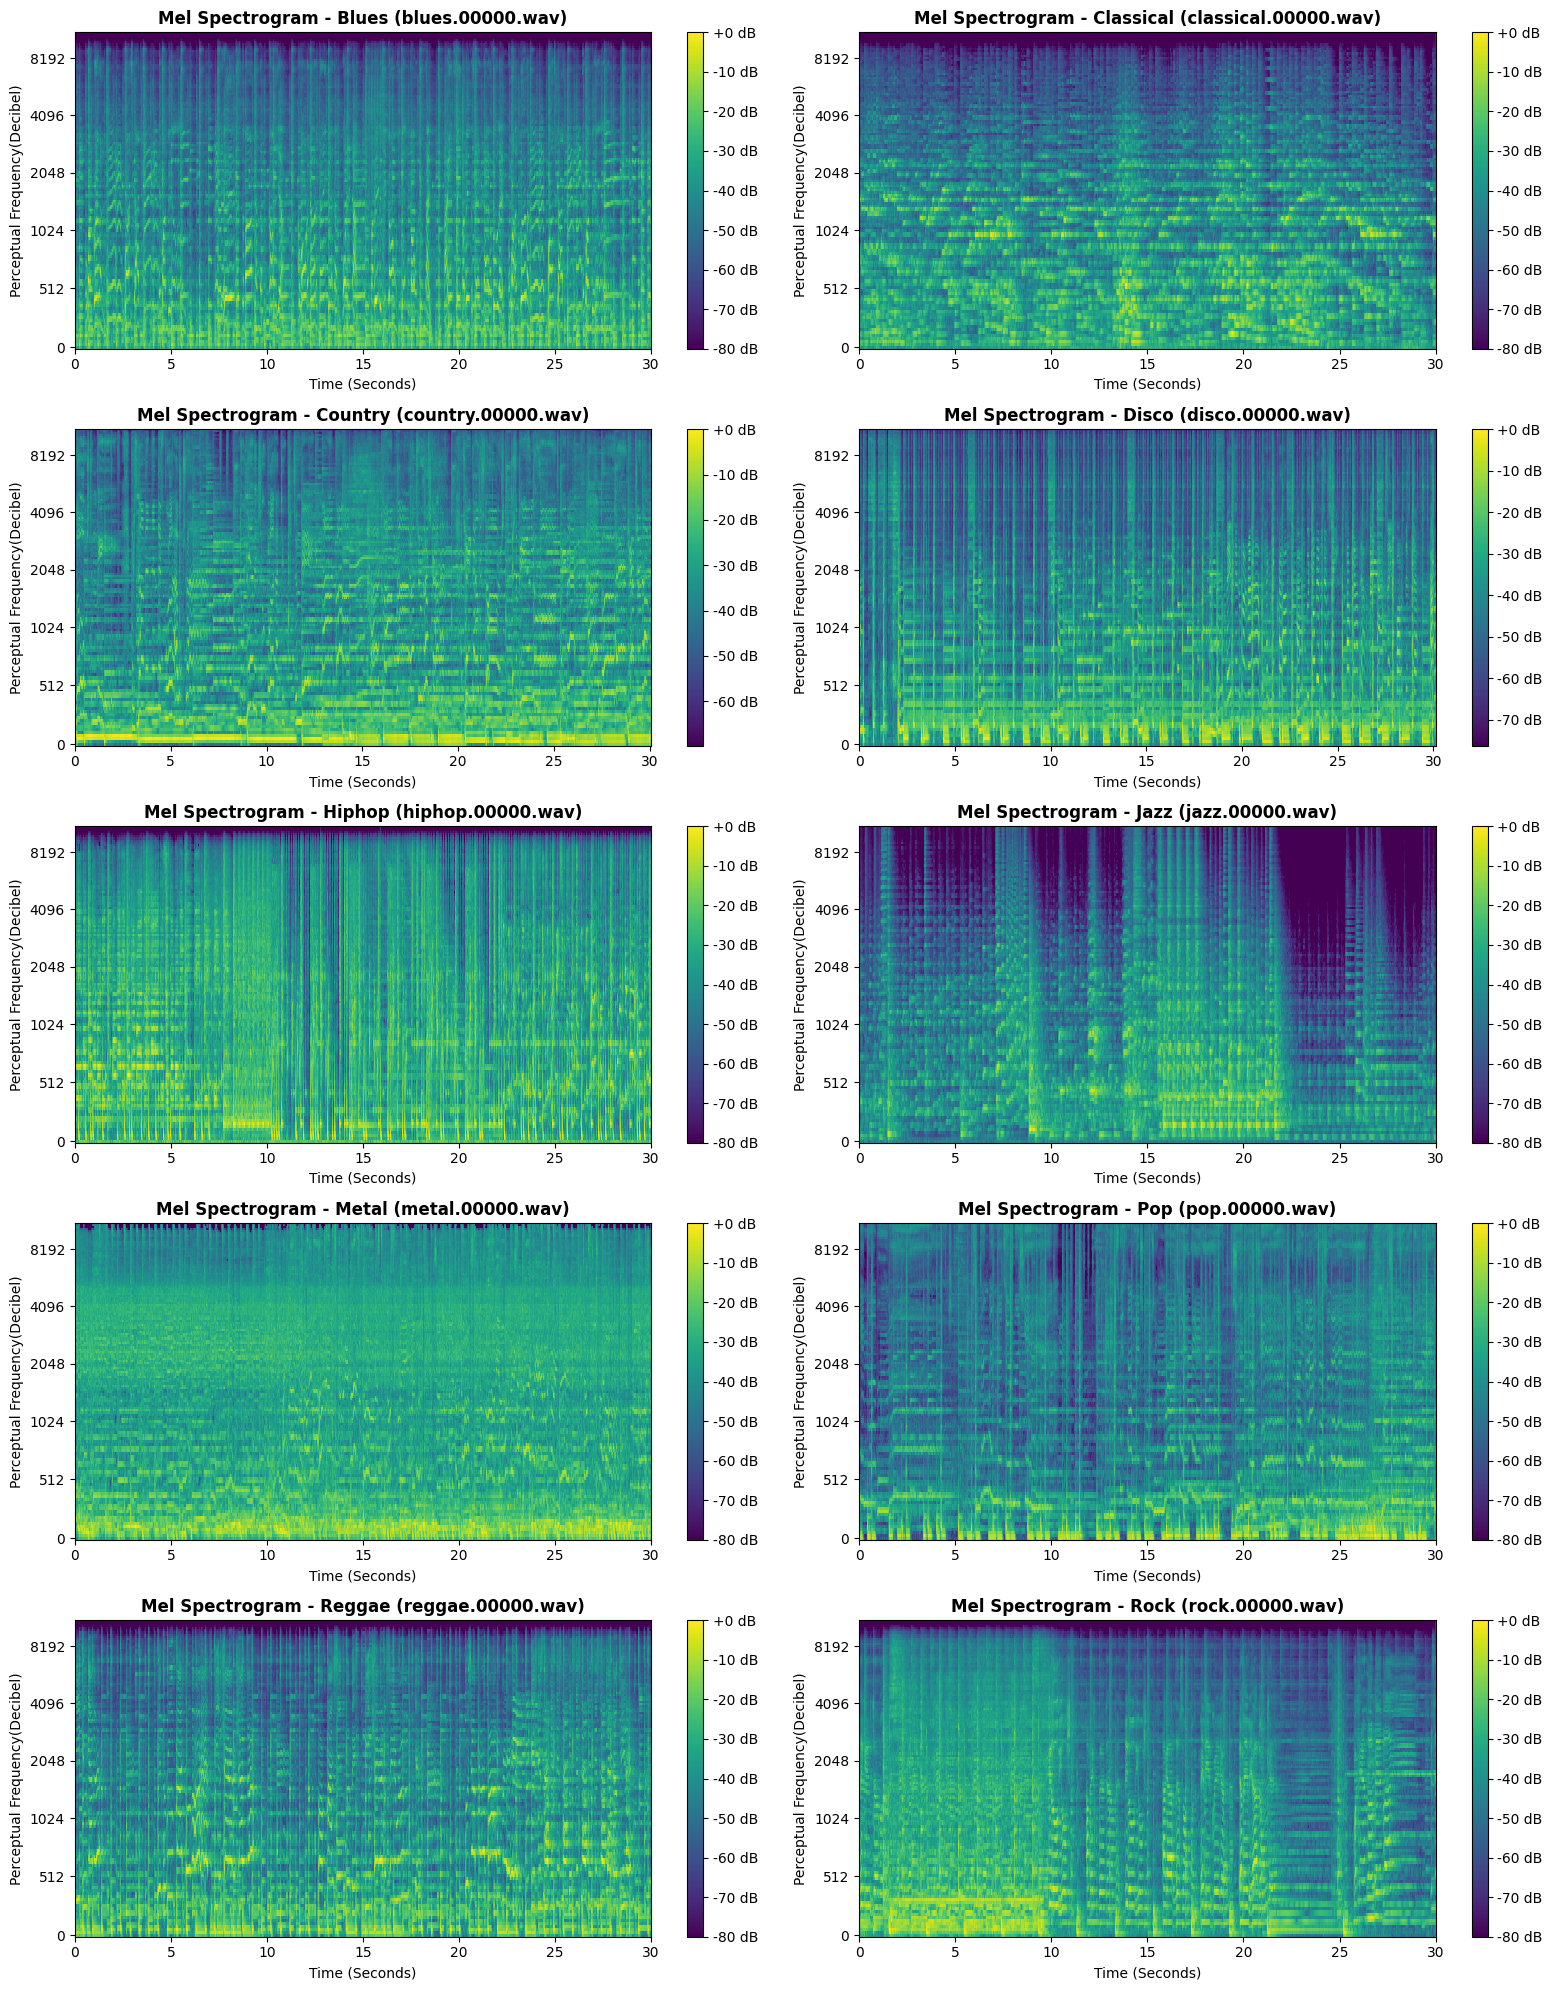

In [ ]:
# 1. Save all audio files (Master dataset is now complete in memory)
final_dataset = mel_spectrograms_db
print(f"Saved {len(final_dataset)} total spectrograms in memory.")

# 2. Display only the spectrogram of the same 10 previewed audio files
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

plot_idx = 0
for genre, file_name, mel_db, sr in final_dataset:
    if file_name in previewed_files: # Match against the 10 displayed earlier
        ax = axes[plot_idx]
        img = librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', sr=sr, cmap='viridis', ax=ax)

        ax.set_title(f'Mel Spectrogram - {genre.capitalize()} ({file_name})', fontweight='bold')
        ax.set_xlabel('Time (Seconds)')
        ax.set_ylabel('Perceptual Frequency(Decibel)') # Human-Like Hearing/Auditory Pitch (Log Scale)/Mel Scale
        fig.colorbar(img, ax=ax, format='%+2.0f dB')

        plot_idx += 1

plt.tight_layout()
plt.show()

Phase 2: Prepare, normalize, and split data for CNN

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

Cell 6: Standardize and Slice Spectrograms (Data Augmentation)

In [ ]:
TARGET_WIDTH = 1290
NUM_SLICES = 10
SLICE_WIDTH = TARGET_WIDTH // NUM_SLICES # 129 frames per chunk (approx 3 seconds)

X, y = [], []

for genre, file_name, mel_db, sr in final_dataset:
    # 1. Standardize to exactly 1290 first
    if mel_db.shape[1] > TARGET_WIDTH:
        mel_db = mel_db[:, :TARGET_WIDTH]
    elif mel_db.shape[1] < TARGET_WIDTH:
        pad_width = TARGET_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, pad_width=((0, 0), (0, pad_width)), mode='constant', constant_values=np.min(mel_db))

    # 2. Slice into 10 separate chunks
    for i in range(NUM_SLICES):
        start = i * SLICE_WIDTH
        end = start + SLICE_WIDTH
        slice_db = mel_db[:, start:end]

        X.append(slice_db)
        y.append(genre)

X = np.array(X)
y = np.array(y)

print(f"Augmented Dataset Shape: {X.shape}")

Augmented Dataset Shape: (9990, 128, 129)


Cell 7: Add Channel Dimension for CNN (Batch, Height, Width, Channels)

In [ ]:
X = X[..., np.newaxis]

Cell 8: Normalize Data to [0, 1] range (Crucial for Neural Network convergence)

In [ ]:
X = (X - np.min(X)) / (np.max(X) - np.min(X))

Cell 9: Encode Text Labels into Integers (e.g., 'blues' -> 0, 'rock' -> 9)

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

Cell 10: Split Data: 70% Training, 15% Validation, 15% Testing

In [ ]:
# First split: 85% Train+Val, 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)
# Second split: 70% Train, 15% Val (0.1765 of 85% is ~15%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f"Training set:   {X_train.shape} | Labels: {y_train.shape}")
print(f"Validation set: {X_val.shape}  | Labels: {y_val.shape}")
print(f"Testing set:    {X_test.shape}  | Labels: {y_test.shape}")

Training set:   (6992, 128, 129, 1) | Labels: (6992,)
Validation set: (1499, 128, 129, 1)  | Labels: (1499,)
Testing set:    (1499, 128, 129, 1)  | Labels: (1499,)


Phase 3: Dataset Preparation and Architecture Definition

Cell 11: Create PyTorch DataLoaders

PyTorch requires data to be channels-first (Batch, Channels, Height, Width), so we rearrange the axes of your existing NumPy arrays before wrapping them into DataLoaders.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert NumPy arrays to Tensors and swap dimensions to Channels-First (Batch, 1, 128, 1290)
X_train_pt = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_pt = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_pt = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train_pt = torch.tensor(y_train, dtype=torch.long)
y_val_pt = torch.tensor(y_val, dtype=torch.long)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

# 2. Package into PyTorch Datasets
train_dataset = TensorDataset(X_train_pt, y_train_pt)
val_dataset = TensorDataset(X_val_pt, y_val_pt)
test_dataset = TensorDataset(X_test_pt, y_test_pt)

# 3. Create DataLoaders for batch processing
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders successfully built. Train Batches: {len(train_loader)}")

DataLoaders successfully built. Train Batches: 219


Cell 12: Transfer Learning with Pre-trained ResNet18

In [ ]:
import torch.nn as nn
import torchvision.models as models

class TransferLearningMusicModel(nn.Module):
    def __init__(self):
        super(TransferLearningMusicModel, self).__init__()

        # 1. Load the pre-trained ResNet18 (Keeps all layers intact)
        self.resnet = models.resnet18(pretrained=True)

        # 2. Replace ONLY the final fully connected layer for our 10 genres
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_features, 10)

        # Optional: Add dropout to the final layer to prevent overfitting on the new data
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        # MAGIC TRICK: x is (Batch, 1, Height, Width)
        # We duplicate the 1 channel 3 times to make it act like an RGB image.
        # Shape becomes (Batch, 3, Height, Width). ALL pre-trained weights are preserved!
        x = x.repeat(1, 3, 1, 1)

        return self.resnet(x)

Cell 13: Compile the Model (Setup Device, Loss, and Optimizer),compiled for Transfer Learning

In [ ]:
import torch

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model and move to GPU/CPU
model = TransferLearningMusicModel().to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: Using a lower learning rate (0.0001) so we don't destroy the pre-trained weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

print(f" Transfer Learning model successfully initialized on: {device}")

 Transfer Learning model successfully initialized on: cuda


Phase 4: Model Training and Validation

Cell 14: Define Training and Validation Functions

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss, train_correct = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    return train_loss / len(train_loader.dataset), train_correct / len(train_loader.dataset)

def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    return val_loss / len(val_loader.dataset), val_correct / len(val_loader.dataset)

Cell 15: Execute Training Loop with Early Stopping

In [ ]:
import copy

EPOCHS = 50
patience = 10
epochs_no_improve = 0

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Fine-Tuning Process...")

for epoch in range(EPOCHS):
    # Run custom functions from Cell 14
    ep_train_loss, ep_train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    ep_val_loss, ep_val_acc = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(ep_train_loss)
    history['train_acc'].append(ep_train_acc)
    history['val_loss'].append(ep_val_loss)
    history['val_acc'].append(ep_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {ep_train_loss:.4f}, Acc: {ep_train_acc:.4f} | Val Loss: {ep_val_loss:.4f}, Acc: {ep_val_acc:.4f}")

    # Early Stopping Logic
    if ep_val_loss < best_val_loss:
        best_val_loss = ep_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\n Early stopping triggered! Validation loss stopped improving for {patience} epochs.")
            break

# Restore optimal state
model.load_state_dict(best_model_wts)
print("Training Complete. Optimal weights restored to model.")

Starting Fine-Tuning Process...
Epoch 1/50 -> Train Loss: 0.0276, Acc: 0.9911 | Val Loss: 0.3548, Acc: 0.9159
Epoch 2/50 -> Train Loss: 0.0344, Acc: 0.9894 | Val Loss: 0.4136, Acc: 0.9033
Epoch 3/50 -> Train Loss: 0.0288, Acc: 0.9906 | Val Loss: 0.3018, Acc: 0.9246
Epoch 4/50 -> Train Loss: 0.0269, Acc: 0.9898 | Val Loss: 0.3298, Acc: 0.9199
Epoch 5/50 -> Train Loss: 0.0372, Acc: 0.9873 | Val Loss: 0.3900, Acc: 0.9079
Epoch 6/50 -> Train Loss: 0.0295, Acc: 0.9907 | Val Loss: 0.3873, Acc: 0.9066
Epoch 7/50 -> Train Loss: 0.0279, Acc: 0.9900 | Val Loss: 0.2783, Acc: 0.9320
Epoch 8/50 -> Train Loss: 0.0120, Acc: 0.9961 | Val Loss: 0.2523, Acc: 0.9413
Epoch 9/50 -> Train Loss: 0.0071, Acc: 0.9977 | Val Loss: 0.2402, Acc: 0.9406
Epoch 10/50 -> Train Loss: 0.0198, Acc: 0.9940 | Val Loss: 0.2970, Acc: 0.9253
Epoch 11/50 -> Train Loss: 0.0185, Acc: 0.9930 | Val Loss: 0.3095, Acc: 0.9233
Epoch 12/50 -> Train Loss: 0.0232, Acc: 0.9913 | Val Loss: 0.3024, Acc: 0.9219
Epoch 13/50 -> Train Loss: 0.

Phase 5: Evaluation, Visualization, and Saving

Cell 16: Evaluate on Unseen Testing Dataset

In [ ]:
model.eval()
test_correct = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)

        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / len(test_loader.dataset)
print(f" Final Accuracy on Test Dataset: {test_acc * 100:.2f}%")

 Final Accuracy on Test Dataset: 93.66%


Cell 17: Plot Loss and Accuracy Curves

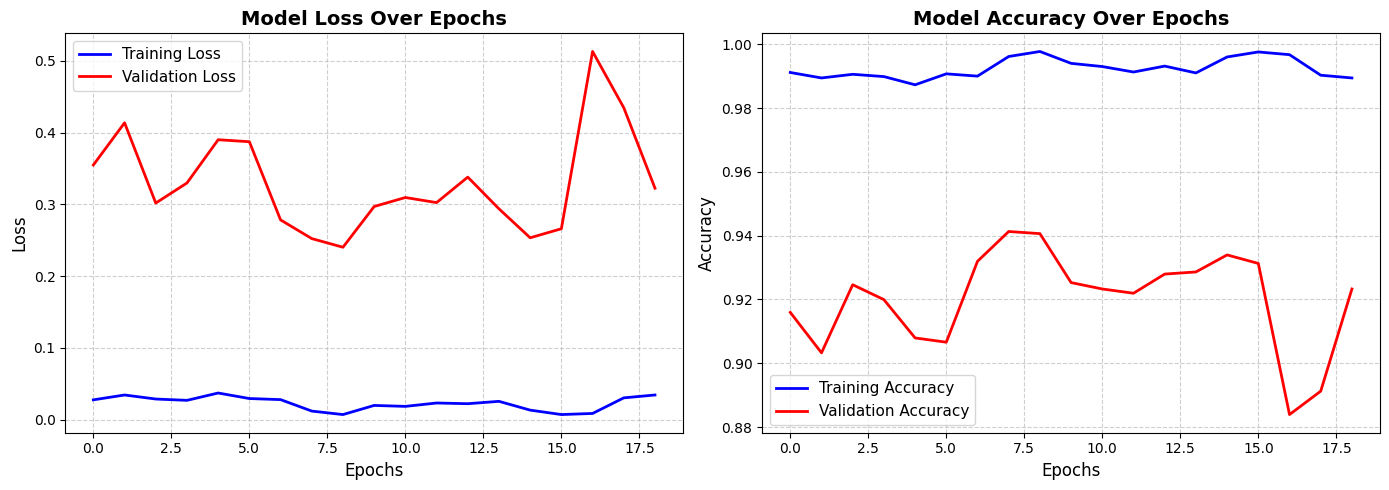

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Curves
axes[0].plot(history['train_loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Accuracy Curves
axes[1].plot(history['train_acc'], label='Training Accuracy', color='blue', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Cell 18: Plot Confusion Matrix

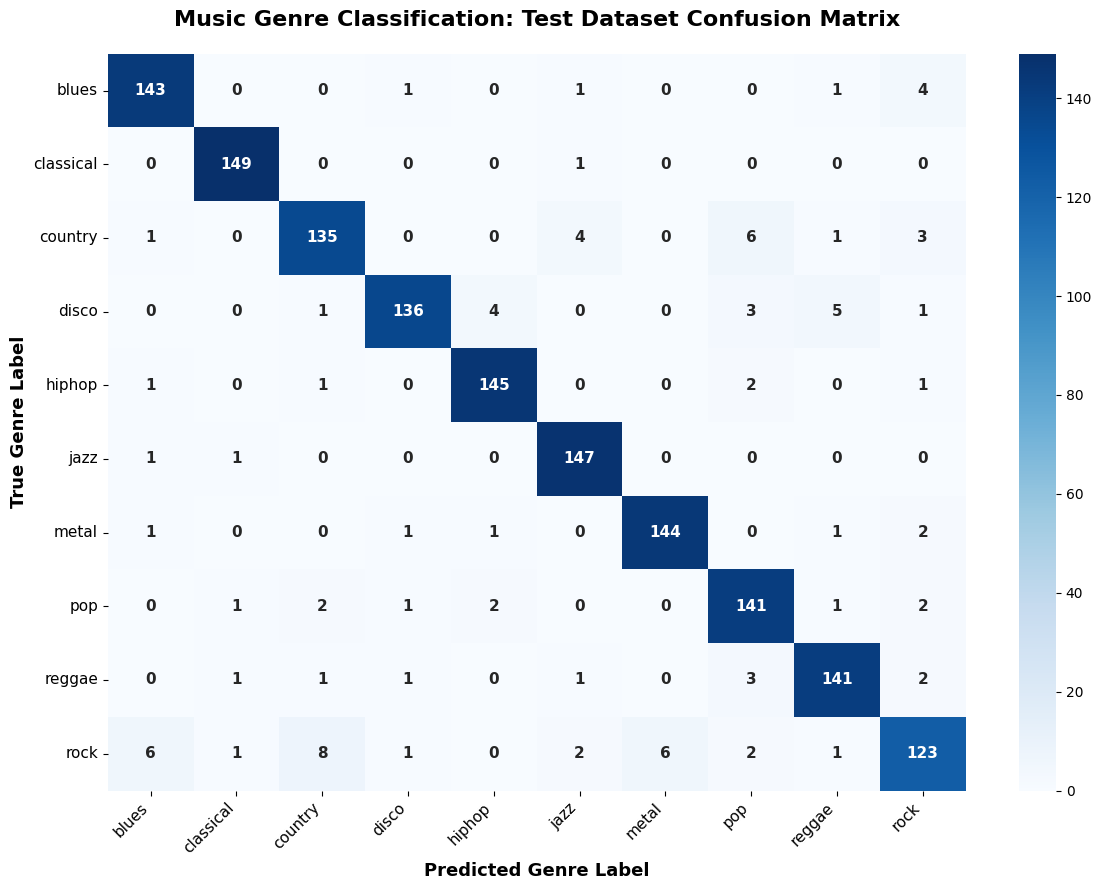

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 9))

# Generate matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot heatmap (Uses 'encoder' from your data prep stage for text labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            annot_kws={"size": 11, "weight": "bold"})

plt.title('Music Genre Classification: Test Dataset Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Genre Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Genre Label', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

Cell 19: Save Final Model

In [ ]:
save_path = 'resnet_music_genre.pth'
torch.save(model.state_dict(), save_path)
print(f"Transfer Learning model saved successfully to: {save_path}")

Transfer Learning model saved successfully to: resnet_music_genre.pth
